# HamLib → Azure QDK vs. Qualtran: Side-by-Side Resource Estimation

This notebook walks through the complete resource-estimation pipeline step by step,
displaying every intermediate output.

## Synthesis modes

The pipeline supports two distinct comparison modes controlled by
`cfg.transpile.rotation_synthesis_enabled`:

| Mode | `rotation_synthesis_enabled` | What both estimators receive |
|------|------------------------------|------------------------------|
| **Synthesis enabled** | `True` | Pure Clifford+T circuit (T/S/H/CX only — no Rz). BQSKit or Solovay-Kitaev synthesises all rotations **before** estimation. Both estimators work from the same gate set. |
| **Synthesis disabled** | `False` (passthrough) | Circuit with arbitrary Rz rotations preserved. Each estimator performs its own internal rotation synthesis. Differences in T count reflect different synthesis algorithms. |

> **Apples-to-apples comparison**: `rotation_synthesis_enabled=True` gives the
> cleanest comparison of physical resource models (same Clifford+T input).
> `rotation_synthesis_enabled=False` shows the estimators' native synthesis
> behaviour but differences in T count may reflect synthesis strategy rather than
> hardware model differences.

## Pipeline overview

```
HamLib HDF5
  └─ Step 1 ─ Load Hamiltonian       → SparsePauliOp + metadata
       └─ Step 2 ─ Build evolution circuit  → QuantumCircuit (Trotter)
            └─ Step 3 ─ Transpile / synthesise  → output circuit (mode-dependent)
                 ├─ Step 4 ─ Azure QDK estimate  → EstimationResult
                 └─ Step 5 ─ Qualtran estimate    → EstimationResult
                      └─ Step 6 ─ Compare         → side-by-side tables
```

All knobs live in `resourceEstimationPipeline/config.py`. Change parameters there
or override them in the **Configuration** cell below.

## Imports

In [1]:
import sys, os
import pathlib
# print(sys.executable)

# Locate the repo root: walk up from CWD until we find the directory that
# contains the resourceEstimationPipeline package.  Works regardless of
# whether Jupyter is launched from the repo root, the notebook directory,
# or anywhere else.
_search = pathlib.Path.cwd()
for _ in range(8):
    if (_search / "resourceEstimationPipeline").is_dir():
        REPO_ROOT = str(_search)
        break
    _search = _search.parent
else:
    REPO_ROOT = str(pathlib.Path.cwd())

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", "{:.4g}".format)

from IPython.display import display, Markdown

# Pipeline modules
from resourceEstimationPipeline.config import (
    PipelineConfig,
    HamlibConfig,
    EvolutionConfig,
    TranspileConfig,
    AzureConfig,
    QualtranConfig,
)
# Cache-aware pipeline runner — handles Steps 1-3 with automatic QASM caching.
# Direct module imports (load_hamiltonian, build_evolution_circuit,
# transpile_to_clifford_t) are intentionally omitted here; the notebook
# routes all circuit-building through pipeline.run() so caching is
# transparent and logic lives in exactly one place.
from resourceEstimationPipeline import pipeline
from resourceEstimationPipeline.compare.metrics import compare
from resourceEstimationPipeline.compare.tables import (
    comparison_dataframe,
    differences_dataframe,
    missing_dataframe,
)

# Connector: bridges Azure results into Qualtran config for direct estimator calls.
# When use_azure_parameters=True is set in QualtranConfig, call this helper
# between Step 4 and Step 5 to inject Azure's chosen code distance and factory count.
from resourceEstimationPipeline.estimators.azure import apply_azure_to_qualtran

print(f"REPO_ROOT: {REPO_ROOT}")
print("Imports OK")

REPO_ROOT: /Users/kevinli/Documents/resourceEstimation
Imports OK


## Configuration

All pipeline parameters are consolidated here. Edit this cell to change the
Hamiltonian, evolution strategy, or estimator settings.

In [2]:
cfg = PipelineConfig(
    hamlib=HamlibConfig(
        # hdf5_path=os.path.join(REPO_ROOT, "hamlib", "condensedmatter", "heisenberg", "heis.hdf5"),
        # hdf5_path=os.path.join(REPO_ROOT, "hamlib", "condensedmatter", "bosehubbard", "BH_D-1_d-4.hdf5"),
        hdf5_path=os.path.join(REPO_ROOT, "hamlib", "condensedmatter", "fermihubbard", "FH_D-1.hdf5"),
        # |  3564 |      50 |    80.000000 |      160 | /Users/kevinli/Documents/resourceEstimation/hamlib/condensedmatter/fermihubbard/FH_D-2.hdf5/fh-graph-2D-grid-nonpbc-qubitnodes_Lx-5_Ly-5_U-0_enc-bk

        # hdf5_path=os.path.join(REPO_ROOT, "hamlib", "condensedmatter", "lattices", "Grids.hdf5"),
        # hdf5_path=os.path.join(REPO_ROOT, "hamlib", "condensedmatter", "bosehubbard", "BH_D-1_d-4.hdf5"),
        # |    15 |     200 |  3979.998969 |     3469 | /Users/kevinli/Documents/resourceEstimation/hamlib/condensedmatter/bosehubbard/BH_D-1_d-4.hdf5/bh_graph-1D-grid-nonpbc-qubitnodes_Lx-100_U-10_enc-gray_d-4

        # hdf5_path="/Users/kevinli/Documents/resourceEstimation/hamlib/discreteoptimization/maxkcut/color02/ham-unary-color02-dsjc250.9_k-4.hdf5", # hierarchical
        # hdf5_path="/Users/kevinli/Documents/resourceEstimation/hamlib/condensedmatter/fermihubbard/FH_D-2.hdf5", #flat
        key=None,         # None → use key_index below
        key_index=39    # Pick a specific Hamiltonian by position in the file
    ),
    evolution=EvolutionConfig(
        evolution_time=1.0,
        synthesis_order=2,   # SuzukiTrotter order (1 or 2)
        synthesis_reps=10,   # number of Trotter repetitions
    ),
    transpile=TranspileConfig(
        optimization_level=1,
        seed_transpiler=42,      # deterministic output
        rotation_synthesis_enabled=False,
        rotation_synthesis_epsilon=1e-4,
        synthesis_strategy="synth",
        synthesis_method='bqskit',         # BQSKit FT (default) or 'solovay_kitaev'
    ),
    azure=AzureConfig(
        error_budget=0.01,
        error_rate=1e-3,
        gate_time_ns=50.0,
        measurement_time_ns=100.0,
        two_qubit_gate_time_ns=50.0,
        # code_distance=17,
        factory_type="RoundBased",   # 'Litinski19' or 'RoundBased'
        slow_down_factors=[1.0],
        optimization_level=1,
        use_graph=True,
        use_qualtran_parameters=False,
        minimize="qubit_hours",
        pareto_index=0,
    ),
    qualtran=QualtranConfig(
        data_d=23,
        # data_d_sweep=[17, 19, 21, 23, 25, 27, 29, 31],
        phys_err=1e-3,
        # cycle_time_us=1.0,
        error_budget=.01,
        data_block="fast",
        factory_type="15to1",        # magic-state factory (used in custom cost-model path)
        n_factories=6,
        use_gidney_fowler=False,
        use_beverland=True,
        use_azure_parameters=False,
        optimize_factory=True,
        optimize_factory_d_max=50,
        pareto_index=0,
    ),
)

print(cfg)

PipelineConfig(hamlib=HamlibConfig(hdf5_path='/Users/kevinli/Documents/resourceEstimation/hamlib/condensedmatter/fermihubbard/FH_D-1.hdf5', key=None, key_index=39), evolution=EvolutionConfig(evolution_time=1.0, synthesis_order=2, synthesis_reps=10), transpile=TranspileConfig(basis_gates=['cx', 'cz', 'h', 's', 'sdg', 'swap', 'x', 'y', 'z', 't', 'tdg', 'rz'], optimization_level=1, seed_transpiler=42, rotation_synthesis_enabled=False, rotation_synthesis_epsilon=0.0001, synthesis_strategy='synth', synthesis_method='bqskit', pygridsynth_precision=None), azure=AzureConfig(error_budget=0.01, error_rate=0.001, gate_time_ns=50.0, measurement_time_ns=100.0, two_qubit_gate_time_ns=50.0, code_distance=None, factory_type='RoundBased', slow_down_factors=[1.0], optimization_level=1, use_graph=True, use_qualtran_parameters=False, minimize='qubit_hours', pareto_index=0), qualtran=QualtranConfig(data_d=23, data_d_sweep=None, phys_err=0.001, t_gate_ns=50.0, t_meas_ns=100.0, cycle_time_us=1.0, error_budge

## Synthesis Method Selection

`cfg.transpile.rotation_synthesis_enabled` controls whether rotation synthesis
happens **before** estimation (shared input) or is left to each estimator.

**When `rotation_synthesis_enabled=True`** — synthesis method applies:

| `synthesis_method` | Description |
|--------------------|-------------|
| **bqskit** (default) | BQSKit + BQSKit-FT `CliffordTModel`; holistic Clifford+T compilation |
| **solovay_kitaev** (legacy) | Qiskit Solovay-Kitaev pass; higher T-count, no extra deps |

**When `rotation_synthesis_enabled=False`** — synthesis_method is ignored.
Both estimators receive the raw transpiled circuit with Rz gates intact.

### What each estimator does with Rz gates

| Estimator | With synthesis enabled | With synthesis disabled |
|-----------|----------------------|------------------------|
| **Azure QDK** | No Rz gates to synthesise. `t_per_rotation=0`. | PSSPC synthesises **all** Rz as arbitrary rotations, including special angles (π/4, π/2, …). |
| **Qualtran** | No Rz gates. `rotation_count=0`. Budget fraction recalculated. | `_rz_to_bloqs` recognises exact Clifford/T angles (π/4→T, π/2→S, …) — only truly arbitrary Rz count toward rotation synthesis. |

> This creates a systematic T-count difference in passthrough mode: Azure counts
> all Rz, Qualtran only counts non-Clifford ones. In synthesis mode both estimators
> start from identical T/S/H/CX gate counts.

---
## Step 1 — Load Hamiltonian

Read a Hamiltonian from a HamLib HDF5 file and convert it to a Qiskit `SparsePauliOp`.

The loader uses `read_qiskit_hdf5` to decode the HamLib bytes directly into a
`SparsePauliOp`, and extracts metadata (`nqubits`, `one_norm`, `terms`) from HDF5
attributes.

In [3]:
# ── Steps 1-3: cache-aware circuit load via pipeline.run() ─────────────────
# Decision flow (handled transparently inside the pipeline):
#   bqskit_<idx>.qasm exists  → load C+T circuit directly; skip build + synthesis
#   evolved_<idx>.qasm exists → load raw circuit, run BQSKit, save bqskit file
#   neither exists            → build evolved circuit, save it, run BQSKit, save it
#
# Cache directory: data/hamlib/<domain>/<type>/[<subcategory>/]<stem>/
# Files: evolved_<key_index>.qasm  and  bqskit_<key_index>.qasm
_pipeline_result = pipeline.run(cfg, run_azure=False, run_qualtran=False)

if _pipeline_result.errors:
    for _step, _msg in _pipeline_result.errors.items():
        print(f"ERROR [{_step}]: {_msg}")
    raise RuntimeError("Pipeline circuit-build step failed — see errors above.")

ham_data    = _pipeline_result.ham_data
raw_circuit = _pipeline_result.raw_circuit      # None when bqskit cache was hit
raw_stats   = _pipeline_result.raw_stats        # {}   when bqskit cache was hit
ct_circuit  = _pipeline_result.clifford_t_circuit
ct_stats    = _pipeline_result.ct_stats
qasm_source = _pipeline_result.qasm_source

# ─── Step 1 display ────────────────────────────────────────────────────────
print(f"HDF5 file : {ham_data.hdf5_path}")
print(f"Dataset key: {ham_data.key}")
print(f"Qubits    : {ham_data.nqubits}")
print(f"Terms     : {ham_data.n_terms}")
print(f"1-norm (λ): {ham_data.one_norm}")
print()
print("SparsePauliOp summary:")
print(f"  num_qubits = {ham_data.pauli_op.num_qubits}")
print(f"  size       = {len(ham_data.pauli_op)} terms")
print()
print("First 5 Pauli terms (label, coefficient):")
for _label, _coeff in zip(
    ham_data.pauli_op.paulis.to_labels()[:5],
    ham_data.pauli_op.coeffs[:5],
):
    print(f"  {_label}  →  {_coeff:.6g}")

[1/6] Loaded Hamiltonian: HamiltonianData(key='fh-graph-1D-grid-nonpbc-qubitnodes_Lx-10_U-12_enc-bk', nqubits=20, n_terms=67, one_norm=138.0)
[2/6] Cache hit (passthrough) — skipping evolution and synthesis.
[cache] Loaded ← /Users/kevinli/Documents/resourceEstimation/resourceEstimationPipeline/data/hamlib/condensedmatter/fermihubbard/FH_D-1/passthrough_39.qasm
[3/6] (skipped — loaded from passthrough cache): depth=18720, T=0, Rz=14250, Clifford=32180
[4/6] Azure estimator skipped.
[5/6] Qualtran estimator skipped.
[6/6] No results to compare.
HDF5 file : /Users/kevinli/Documents/resourceEstimation/hamlib/condensedmatter/fermihubbard/FH_D-1.hdf5
Dataset key: fh-graph-1D-grid-nonpbc-qubitnodes_Lx-10_U-12_enc-bk
Qubits    : 20
Terms     : 67
1-norm (λ): 138.0

SparsePauliOp summary:
  num_qubits = 20
  size       = 67 terms

First 5 Pauli terms (label, coefficient):
  IIIIIIIIIIIIIIIIIIII  →  30+0j
  XIIIIIIIIIIIIIIIIIII  →  -0.5+0j
  XZIIIIIIIIIIIIIIIIII  →  0.5+0j
  ZIIIIIIIIIIIIIIIIII

---
## Step 2 — Build Evolution Circuit

Build a Trotterized circuit for $e^{-iHt}$ using Qiskit's `PauliEvolutionGate`
with `SuzukiTrotter` synthesis.

The circuit contains a single high-level `PauliEvolutionGate`; transpilation in
Step 3 decomposes it into the canonical Clifford+T basis.

In [4]:
# Step 2 display — raw evolution circuit (built or loaded from cache in step above)
print(f"Evolution      : PauliEvolutionGate (SuzukiTrotter order={cfg.evolution.synthesis_order}, reps={cfg.evolution.synthesis_reps})")
print(f"Evolution time : t = {cfg.evolution.evolution_time}")
print()

if raw_circuit is not None:
    print("Raw circuit statistics:")
    print(f"  Qubits      : {raw_stats['num_qubits']}")
    print(f"  Depth       : {raw_stats['depth']:,}")
    print(f"  Total gates : {raw_stats['total_gates']:,}")
    print(f"  Gate counts : {raw_stats['gate_counts']}")
else:
    print("(BQSKit circuit was loaded from cache — raw circuit not rebuilt.)")
    print("Raw circuit statistics not available for this run.")

Evolution      : PauliEvolutionGate (SuzukiTrotter order=2, reps=10)
Evolution time : t = 1.0

(BQSKit circuit was loaded from cache — raw circuit not rebuilt.)
Raw circuit statistics not available for this run.


In [5]:
# BQSKit pre-compile gate preview (only available when raw circuit was not cached)
if raw_circuit is not None:
    from bqskit.ext import qiskit_to_bqskit
    bqskit_preview = qiskit_to_bqskit(raw_circuit)
    print('BQSKit pre-compile gate counts:', bqskit_preview.gate_counts)
    print('Num qudits:', bqskit_preview.num_qudits)
    print('(Full Clifford+T compilation ran via the pipeline cache system.)')
else:
    print("(raw circuit not available — bqskit_<idx>.qasm cache hit; BQSKit preview skipped)")

(raw circuit not available — bqskit_<idx>.qasm cache hit; BQSKit preview skipped)


In [6]:
# ct_circuit is set by pipeline.run() in the Steps 1-3 cell above.
# This cell is a no-op and can be safely skipped.

In [7]:
_synth_enabled_display = (
    cfg.transpile.rotation_synthesis_enabled
    and cfg.transpile.synthesis_strategy != "passthrough"
)
_mode_display = (
    f"Clifford+T (synthesis={cfg.transpile.synthesis_method})"
    if _synth_enabled_display
    else "passthrough (rotation_synthesis_enabled=False)"
)

print(f"Output circuit mode: {_mode_display}")
print()
print("Output circuit statistics:")
print(f"  Qubits         : {ct_stats['num_qubits']}")
print(f"  Depth          : {ct_stats['depth']:,}")
print(f"  Total gates    : {ct_stats['total_gates']:,}")
print(f"  T count        : {ct_stats['t_count']:,}")
print(f"  Clifford count : {ct_stats['clifford_count']:,}")
print(f"  Rz count       : {ct_stats['rz_count']:,}")
print(f"  Gate breakdown : {ct_stats['gate_counts']}")
print()
if _synth_enabled_display:
    print("→ Both estimators receive a pure Clifford+T circuit (no Rz).")
    print("  Rotation synthesis is NOT performed again by either estimator.")
else:
    print("→ Both estimators receive a circuit with Rz gates.")
    print("  Azure QDK will synthesise all Rz internally via PSSPC.")
    print("  Qualtran will classify exact-angle Rz as Clifford/T and synthesise the rest.")

Output circuit mode: passthrough (rotation_synthesis_enabled=False)

Output circuit statistics:
  Qubits         : 20
  Depth          : 18,720
  Total gates    : 46,430
  T count        : 0
  Clifford count : 32,180
  Rz count       : 14,250
  Gate breakdown : {'sdg': 19000, 'rz': 14250, 'h': 9500, 'cx': 3680}

→ Both estimators receive a circuit with Rz gates.
  Azure QDK will synthesise all Rz internally via PSSPC.
  Qualtran will classify exact-angle Rz as Clifford/T and synthesise the rest.


### Circuit diagram (first few qubits)

Draws the first 4 qubits and the first 40 moments of the raw circuit.

In [8]:
# Show a slice of the circuit for readability
n_show = min(4, ct_circuit.num_qubits)
try:
    from qiskit import QuantumCircuit
    # Slice: take first n_show qubits and first 40 operations
    ops_all = ct_circuit.data
    slice_ops = [op for op in ops_all if all(ct_circuit.find_bit(q).index < n_show for q in op.qubits)][:40]
    qc_slice = QuantumCircuit(n_show)
    for op in slice_ops:
        idx = [ct_circuit.find_bit(q).index for q in op.qubits]
        qc_slice.append(op.operation, idx)
    print(qc_slice.draw(fold=120))
except Exception as e:
    print(f"(diagram unavailable: {e})")
    print(ct_circuit)

     ┌───────┐  ┌─────┐   ┌───┐ ┌─────┐┌──────────┐ ┌─────┐  ┌───┐ ┌─────┐┌────────┐                                  »
q_0: ┤ Rz(π) ├──┤ Sdg ├───┤ H ├─┤ Sdg ├┤ Rz(3π/2) ├─┤ Sdg ├──┤ H ├─┤ Sdg ├┤ Rz(3π) ├──────────────────────────────────»
     └───────┘  └─────┘   └───┘ └─────┘└──────────┘ └─────┘  └───┘ └─────┘└────────┘                                  »
q_1: ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────»
       ┌───┐  ┌─────────┐┌─────┐ ┌───┐   ┌─────┐   ┌───────┐┌─────┐ ┌───┐  ┌─────┐  ┌────────┐┌───┐ ┌───────┐  ┌─────┐»
q_2: ──┤ X ├──┤ Rz(0.3) ├┤ Sdg ├─┤ H ├───┤ Sdg ├───┤ Rz(π) ├┤ Sdg ├─┤ H ├──┤ Sdg ├──┤ Rz(3π) ├┤ X ├─┤ Rz(π) ├──┤ Sdg ├»
       └─┬─┘  └─────────┘└─────┘ └───┘   └─────┘   └───────┘└─────┘ └───┘  └─────┘  └────────┘└─┬─┘┌┴───────┴─┐├─────┤»
q_3: ────■──────────────────────────────────────────────────────────────────────────────────────■──┤ Rz(-π/2) ├┤ Sdg ├»
                                        

### Circuit stats comparison: raw → Clifford+T

In [9]:
rows = []
if raw_stats:  # empty dict ({}) when bqskit cache was hit — raw circuit not loaded
    rows.append({
        "Stage": "Raw (pre-transpile)",
        "Qubits":      raw_stats["num_qubits"],
        "Depth":       raw_stats["depth"],
        "Total gates": raw_stats["total_gates"],
        "T count":     raw_stats["t_count"],
        "Clifford":    raw_stats["clifford_count"],
        "Rz":          raw_stats["rz_count"],
    })
rows.append({
    "Stage": "Clifford+T (transpiled)",
    "Qubits":      ct_stats["num_qubits"],
    "Depth":       ct_stats["depth"],
    "Total gates": ct_stats["total_gates"],
    "T count":     ct_stats["t_count"],
    "Clifford":    ct_stats["clifford_count"],
    "Rz":          ct_stats["rz_count"],
})

stats_df = pd.DataFrame(rows).set_index("Stage")
display(stats_df)
if not raw_stats:
    print("(Raw circuit row omitted — BQSKit circuit was loaded from cache.)")

,Qubits,Depth,Total gates,T count,Clifford,Rz
Stage,,,,,,
Clifford+T (transpiled),20,18720,46430,0,32180,14250


(Raw circuit row omitted — BQSKit circuit was loaded from cache.)


In [10]:
# ── Circuit state validation ─────────────────────────────────────────────────
# Verify the output circuit is in the expected state for the selected mode.
# This catches cache mismatches (e.g. loading a synthesis=True cached circuit
# when the current run uses synthesis=False, or vice versa).

_synth_enabled = (
    cfg.transpile.rotation_synthesis_enabled
    and cfg.transpile.synthesis_strategy != "passthrough"
)
_n_rz   = ct_stats["rz_count"]
_n_t    = ct_stats["t_count"]
_n_rx   = ct_stats["gate_counts"].get("rx", 0)
_n_ry   = ct_stats["gate_counts"].get("ry", 0)
_n_rots = _n_rz + _n_rx + _n_ry

print("=" * 60)
print("Circuit state validation")
print("=" * 60)
print(f"  rotation_synthesis_enabled : {_synth_enabled}")
print(f"  synthesis_method           : {cfg.transpile.synthesis_method if _synth_enabled else 'N/A (passthrough)'}")
print(f"  Circuit rotation gates     : Rz={_n_rz}  Rx={_n_rx}  Ry={_n_ry}  (total={_n_rots})")
print(f"  Circuit T gates            : {_n_t}")
print()

if _synth_enabled:
    if _n_rots > 0:
        print(f"  FAIL: {_n_rots} rotation gate(s) remain after synthesis.")
        print("  This may indicate a cache mismatch. Delete the cached QASM files and re-run.")
    else:
        print("  PASS: No rotation gates (synthesis=enabled). Both estimators receive pure Clifford+T.")
        print(f"  T gates in shared circuit: {_n_t}")
else:
    if _n_rots == 0:
        print("  WARNING: 0 rotation gates in passthrough mode.")
        print("  Expected Rz gates if the Hamiltonian has non-Clifford terms.")
        print("  This may indicate a cache mismatch. Delete cached QASM files and re-run.")
    else:
        print(f"  PASS: {_n_rots} rotation gate(s) preserved (synthesis=disabled).")
        print("  Each estimator will synthesise rotations using its own algorithm.")
        print("  NOTE: T-count differences between estimators may reflect synthesis")
        print("  strategy differences, not hardware model differences.")
print("=" * 60)

Circuit state validation
  rotation_synthesis_enabled : False
  synthesis_method           : N/A (passthrough)
  Circuit rotation gates     : Rz=14250  Rx=0  Ry=0  (total=14250)
  Circuit T gates            : 0

  PASS: 14250 rotation gate(s) preserved (synthesis=disabled).
  Each estimator will synthesise rotations using its own algorithm.
  NOTE: T-count differences between estimators may reflect synthesis
  strategy differences, not hardware model differences.


### OpenQASM 3 export (first 30 lines)

The circuit is exported to OpenQASM 3 and passed directly to the Azure QDK estimator.

In [11]:
# qasm_source is set by pipeline.run() above — no need to re-export
lines = qasm_source.split("\n")
print(f"Total lines: {len(lines)}")
print("\n".join(lines[:30]))
if len(lines) > 30:
    print(f"  ... ({len(lines)} lines total)")

Total lines: 46434
OPENQASM 3.0;
include "stdgates.inc";
qubit[20] q;
rz(pi) q[0];
sdg q[0];
h q[0];
sdg q[0];
rz(3*pi/2) q[0];
sdg q[0];
h q[0];
sdg q[0];
rz(3*pi) q[0];
rz(-pi/2) q[11];
sdg q[11];
h q[11];
sdg q[11];
rz(pi) q[11];
sdg q[11];
h q[11];
sdg q[11];
rz(3*pi) q[11];
rz(pi) q[11];
sdg q[11];
h q[11];
sdg q[11];
rz(3*pi/2) q[11];
sdg q[11];
h q[11];
sdg q[11];
rz(3*pi) q[11];
  ... (46434 lines total)


---
## Step 4 — Azure QDK Resource Estimation

The Azure QDK Resource Estimator (`qdk.qre`) takes:
- An OpenQASM 3 circuit (exported above)
- A physical hardware model (`GateBased` with error rate + gate times)
- A QEC code (`SurfaceCode`) and magic-state factory (`Litinski19Factory`)
- A total error budget (`max_error`)

It sweeps code distances internally and returns a Pareto front of
(physical qubits, runtime) trade-offs.

In [12]:
azure_result = None
_azure_error = None

try:
    from resourceEstimationPipeline.estimators.azure import estimate as azure_estimate
    azure_result = azure_estimate(ct_circuit, cfg)
    print("Azure QDK estimation complete.")
    print(f"  Physical qubits : {azure_result.physical_qubits:,}")
    print(f"  Runtime         : {azure_result.runtime_seconds:.4f} s")
    print(f"  Logical error   : {azure_result.logical_error_rate:.3e}")
    if azure_result.t_per_rotation is not None:
        print(f"  T/rotation      : {azure_result.t_per_rotation}")
    if azure_result.factory_count:
        print(f"  Factory config  : {azure_result.factory_count}")
except ImportError as e:
    _azure_error = f"qdk not installed — {e}"
    print(f"⚠ Azure estimator unavailable: {_azure_error}")
    print("  Install with: pip install qdk")
except Exception as e:
    _azure_error = str(e)
    print(f"⚠ Azure estimation failed: {_azure_error}")

# ── Bridge: inject Azure parameters into Qualtran config ────────────────────
# When use_azure_parameters=True is set in cfg.qualtran, this step passes
# Azure's chosen code distance and factory count into the Qualtran config.
# Without calling apply_azure_to_qualtran, the flag does nothing because
# Qualtran needs the actual values (not just the flag).
if azure_result is not None:
    az_d = azure_result.code_distance
    az_n = azure_result.num_factories
    if cfg.qualtran.use_azure_parameters and (az_d is not None or az_n is not None):
        cfg = apply_azure_to_qualtran(azure_result, cfg)
        print(f"Azure → Qualtran injected: d={az_d}, factories={az_n}")
else:
    print("Skipping Azure → Qualtran bridge: no Azure result.")

Azure QDK estimation complete.
  Physical qubits : 18,258
  Runtime         : 0.0592 s
  Logical error   : 5.075e-03
  T/rotation      : 15
  Factory config  : 1×T


### Azure assumptions

In [13]:
if azure_result is not None:
    print("Algorithm assumptions:")
    print(" ", azure_result.algorithm_assumptions)
    print()
    print("Architecture assumptions:")
    print(" ", azure_result.architecture_assumptions)
else:
    az = cfg.azure
    print("(Azure did not run — assumptions from config)")
    print(f"  error_rate={az.error_rate:.0e}, error_budget={az.error_budget}")
    print(f"  gate_time={az.gate_time_ns} ns, meas_time={az.measurement_time_ns} ns")
    print(f"  factory={az.factory_type}, QEC=SurfaceCode")

Algorithm assumptions:
  rotation_synthesis=disabled; synthesis_method=N/A (passthrough); basis=['cx', 'cz', 'h', 's', 'sdg', 'swap', 'x', 'y', 'z', 't', 'tdg', 'rz']; PauliEvolutionGate SuzukiTrotter order=2 reps=10; t=1.0

Architecture assumptions:
  GateBased error_rate=1e-03; gate_time=50.0 ns; meas_time=100.0 ns; two_qubit_gate_time=50 ns; SurfaceCode QEC d=13; factory=RoundBased


---
## Step 5 — Qualtran Resource Estimation

The Qualtran estimator takes:
- The same canonical Clifford+T circuit, converted to a `CompositeBloq`
- A code distance `data_d` (instead of an error budget)
- A `PhysicalCostModel` (Gidney-Fowler CCZ2T factory by default)

It computes exact logical gate counts from the bloq graph, then maps them
to physical resources using the surface-code cost model.

In [14]:
qualtran_result = None
_qualtran_error = None

try:
    from resourceEstimationPipeline.estimators.qualtran import estimate as qt_estimate
    qualtran_result = qt_estimate(ct_circuit, cfg)
    print("Qualtran estimation complete.")
    print(f"  Physical qubits : {qualtran_result.physical_qubits:,}")
    print(f"  Runtime         : {qualtran_result.runtime_seconds:.4f} s")
    print(f"  Code distance   : {qualtran_result.code_distance}")
    print(f"  T count (total) : {qualtran_result.t_count:,}")
    print(f"  Clifford count  : {qualtran_result.clifford_count:,}")
    print(f"  Rotation count  : {qualtran_result.rotation_count:,}")
    print(f"  Logical qubits  : {qualtran_result.logical_qubits}")
    print(f"  Logical error   : {qualtran_result.logical_error_rate:.3e}")
    print(f"  Rotation error  : {qualtran_result.rotation_error}")
    print(f"  Factory error   : {qualtran_result.factory_error}")
    print(f"  Data error      : {qualtran_result.data_block_error}")
    print(f"  Factory Tuple   : {qualtran_result.factory_tuple}") if cfg.qualtran.optimize_factory else None
except ImportError as e:
    _qualtran_error = f"qualtran not installed — {e}"
    print(f"⚠ Qualtran estimator unavailable: {_qualtran_error}")
    print("  Install with: pip install qualtran")
except Exception as e:
    _qualtran_error = str(e)
    print(f"⚠ Qualtran estimation failed: {_qualtran_error}")

Qualtran estimation complete.
  Physical qubits : 34,596
  Runtime         : 0.4533 s
  Code distance   : 17
  T count (total) : 103,020
  Clifford count  : 40,370
  Rotation count  : 6,060
  Logical qubits  : 20
  Logical error   : 7.502e-03
  Rotation error  : 0.0033333333333333327
  Factory error   : 0.0023331000000000003
  Data error      : 0.0018358164000000009
  Factory Tuple   : (3, 3, 3)


### Qualtran AlgorithmSummary (logical gate counts)

In [15]:
if qualtran_result is not None and "algo_summary" in qualtran_result.extra:
    asm = qualtran_result.extra["algo_summary"]
    asm_df = pd.DataFrame([asm]).T
    asm_df.columns = ["Count"]
    asm_df.index.name = "Metric"
    display(asm_df)
    print()
    print("T-count breakdown:")
    print(f"  T (exact gates)    : {asm['t_exact']:,}")
    print(f"  T (via Rz synth.)  : {asm['t_total'] - asm['t_exact']:,}")
    print(f"  T (total)          : {asm['t_total']:,}")
    # Per-rotation precision derived from global error budget
    if "eps_per_rotation" in qualtran_result.extra:
        eps = qualtran_result.extra["eps_per_rotation"]
        print(f"  eps/rotation       : {eps:.2e} (derived from error_budget)")
else:
    print("(Qualtran did not run or algo_summary unavailable)")

,Count
Metric,
t_exact,0
t_total,103020
rotation_count,6060
clifford_count,40370
toffoli_count,0
and_count,0
measurement,0
n_algo_qubits,20



T-count breakdown:
  T (exact gates)    : 0
  T (via Rz synth.)  : 103,020
  T (total)          : 103,020
  eps/rotation       : 5.50e-07 (derived from error_budget)


### Qualtran assumptions

In [16]:
if qualtran_result is not None:
    print("Algorithm assumptions:")
    print(" ", qualtran_result.algorithm_assumptions)
    print()
    print("Architecture assumptions:")
    print(" ", qualtran_result.architecture_assumptions)
else:
    qt = cfg.qualtran
    print("(Qualtran did not run — assumptions from config)")
    print(f"  data_d={qt.data_d}, phys_err={qt.phys_err:.0e}")
    print(f"  cycle_time={qt.cycle_time_us} µs, factory={qt.factory_type}")

Algorithm assumptions:
  rotation_synthesis=disabled; synthesis_method=N/A (passthrough); basis=['cx', 'cz', 'h', 's', 'sdg', 'swap', 'x', 'y', 'z', 't', 'tdg', 'rz']; eps_per_rotation=5.50e-07 (derived from error_budget=1e-02); rot_count=6060; PauliEvolutionGate SuzukiTrotter order=2 reps=10; t=1.0

Architecture assumptions:
  FifteenToOne factory ×12; surface-code d=17; phys_err=1e-03; cycle_time=0.4 µs; t_gate=50 ns; t_meas=100 ns


---
## Step 6 — Side-by-Side Comparison

The comparison layer operates only on the public fields of `EstimationResult`.
It never reads estimator internals, so results remain comparable as new
estimators are added.

**Interpreting the comparison:**

- **`rotation_synthesis_enabled=True`** (Clifford+T mode): Both estimators received
  the same pure Clifford+T circuit. Differences in physical qubit counts and runtimes
  reflect the estimators' physical hardware models and QEC parameters only.

- **`rotation_synthesis_enabled=False`** (passthrough mode): Both estimators received
  the same circuit *with Rz gates*. T-count differences may reflect:
  - Azure synthesises **all** Rz as arbitrary rotations.
  - Qualtran recognises special angles (multiples of π/4) as exact Clifford/T gates
    — only the remaining truly-arbitrary Rz contribute to T count.
  - This is a legitimate algorithmic difference, not a preprocessing inconsistency.

Check the **"Synthesis note"** and **"Algorithm assumptions"** rows in the table below
to see what mode was active for each result.

In [17]:
from resourceEstimationPipeline.compare.metrics import enrich_from_circuit
azure_result = enrich_from_circuit(azure_result, ct_circuit)
qualtran_result = enrich_from_circuit(qualtran_result, ct_circuit)
available_results = [r for r in [azure_result, qualtran_result] if r is not None]

if not available_results:
    print("No estimation results available — check estimator errors above.")
    report = None
else:
    report = compare(available_results)
    print(f"Estimators compared   : {report.estimator_names}")
    print(f"Shared metrics        : {len(report.shared_metrics)}")
    print(f"N/A in ≥1 estimator   : {len(report.missing_metrics)}")
    print(f"Numeric differences   : {len(report.differences)}")

Estimators compared   : ['Azure QDK (err_rate=1e-03, budget=0.01)', 'Qualtran (d=17, p=1e-03)']
Shared metrics        : 37
N/A in ≥1 estimator   : 6
Numeric differences   : 23


### Full comparison table

In [18]:
if report is not None:
    df = comparison_dataframe(report)
    display(df)
    n_shared = len(report.shared_metrics)
    n_missing = len(report.missing_metrics)
    n_total = len(report.metric_rows)
    display(Markdown(
        f"*{n_total} metrics total — "
        f"**{n_shared} shared** (both estimators report a value) | "
        f"**{n_missing} framework-specific** (N/A in ≥1 estimator) | "
        f"Ratio column shows '—' when values are non-numeric or unavailable.*"
    ))
else:
    print("(no report — run both estimators first)")

with open("comparison_bert.csv", "w") as f:
    f.write(df.to_csv(index=False))

,Metric,"Azure QDK (err_rate=1e-03, budget=0.01)","Qualtran (d=17, p=1e-03)",Ratio (B/A)
0,Logical qubits,20,20,1.000×
1,Logical depth,"18,720","18,720",1.000×
2,Logical cycles,"13,010","66,660",5.124×
3,T count,"213,750","103,020",0.482×
4,T depth,0,0,—
5,T count (from circuit),0,0,—
6,Clifford count,"32,180","40,370",1.255×
7,Rotation count,"14,250","6,060",0.425×
8,Toffoli count,0,0,—
9,Measurement count,0,0,—


*43 metrics total — **37 shared** (both estimators report a value) | **6 framework-specific** (N/A in ≥1 estimator) | Ratio column shows '—' when values are non-numeric or unavailable.*

### Derived comparison metrics

Secondary metrics computed from the primary fields above.
These provide normalized comparisons independent of circuit size.
A metric is N/A when one or both estimators are missing the required input fields.

In [19]:
# Derived metrics: computed from primary fields; N/A when required inputs are missing.
# Ratio is only shown when both estimators have valid values for the required inputs.
_DERIVED_KEYS = [
    "Physical qubits per logical qubit",
    "Factory qubit fraction",
    "Runtime per T gate (s)",
    "T gates per logical qubit",
    "Logical cycles per T gate",
    "Physical qubits per T state",
]

_DERIVED_NOTES = {
    "Physical qubits per logical qubit": "total physical / logical qubits",
    "Factory qubit fraction":            "factory qubits / total physical qubits",
    "Runtime per T gate (s)":            "runtime / T count  [amortised cost per T state]",
    "T gates per logical qubit":         "T count / logical qubits  [algorithm complexity density]",
    "Logical cycles per T gate":         "logical cycles / T count  [approx.; T-dominated schedule]",
    "Physical qubits per T state":       "factory qubits / T count  [amortised factory overhead]",
}

if report is not None:
    names = report.estimator_names
    derived_rows = []
    for key in _DERIVED_KEYS:
        mc = report.get_metric(key)
        if mc is None:
            continue
        row = {
            "Derived Metric": mc.metric,
            "Formula": _DERIVED_NOTES.get(mc.metric, ""),
        }
        for name in names:
            v = mc.values.get(name)
            if v is None:
                row[name] = "N/A"
            elif isinstance(v, float):
                row[name] = f"{v:.4g}"
            elif isinstance(v, int):
                row[name] = f"{v:,}"
            else:
                row[name] = str(v)
        row["Ratio (B/A)"] = f"{mc.ratio:.3f}×" if mc.ratio is not None else "—"
        derived_rows.append(row)

    if derived_rows:
        dm_df = pd.DataFrame(derived_rows).set_index("Derived Metric")
        display(dm_df)
    else:
        print("(no derived metrics available — primary fields missing)")
else:
    print("(no report)")

,Formula,"Azure QDK (err_rate=1e-03, budget=0.01)","Qualtran (d=17, p=1e-03)",Ratio (B/A)
Derived Metric,,,,
Physical qubits per logical qubit,total physical / logical qubits,912.9,1730,1.895×
Factory qubit fraction,factory qubits / total physical qubits,0.003286,0.09781,29.765×
Runtime per T gate (s),runtime / T count [amortised cost per T state],2.769e-07,4.4e-06,15.888×
T gates per logical qubit,T count / logical qubits [algorithm complexity density],1.069e+04,5151,0.482×
Logical cycles per T gate,logical cycles / T count [approx.; T-dominated schedule],0.06087,0.6471,10.631×
Physical qubits per T state,factory qubits / T count [amortised factory overhead],0.0002807,0.03285,117.021×


### Parameter alignment

The table below shows the hardware assumptions each estimator makes.
Parameters with matching values (e.g. `physical_error_rate`, `code_distance`) give the
closest apples-to-apples comparison. Parameters marked N/A have no equivalent
in the other estimator's timing model.

In [20]:
# Parameter alignment table: estimator hardware assumptions side-by-side.
# Match these parameters when trying to get apples-to-apples comparisons.
# N/A means the estimator uses a different timing model (e.g. Azure uses gate_time_ns
# while Qualtran uses cycle_time_us; neither has a direct equivalent in the other).
_PARAM_KEYS = [
    "Physical error rate",
    "Code distance",
    "Cycle time (µs)",
    "Gate time (ns)",
    "Measurement time (ns)",
    "Factory type",
    "Factory config",
    "Rotation synthesis precision (ε)",
    "T gates per rotation",
    "Error budget",
]

if report is not None:
    names = report.estimator_names
    param_rows = []
    for key in _PARAM_KEYS:
        mc = report.get_metric(key)
        if mc is None:
            continue
        row = {"Parameter": mc.metric}
        for name in names:
            v = mc.values.get(name)
            if v is None:
                row[name] = "N/A"
            elif isinstance(v, float):
                row[name] = f"{v:.4g}"
            elif isinstance(v, int):
                row[name] = f"{v:,}"
            else:
                row[name] = str(v)
        param_rows.append(row)

    if param_rows:
        params_df = pd.DataFrame(param_rows).set_index("Parameter")
        display(params_df)
else:
    print("(no report)")

,"Azure QDK (err_rate=1e-03, budget=0.01)","Qualtran (d=17, p=1e-03)"
Parameter,,
Physical error rate,0.001,0.001
Code distance,13,17
Cycle time (µs),0.35,0.4
Gate time (ns),50,50
Measurement time (ns),100,100
Factory type,RoundBased,FifteenToOne
Factory config,1×T,FifteenToOne×12 (282 each)
Rotation synthesis precision (ε),N/A,5.501e-07
T gates per rotation,15,17


### Metrics that differ between estimators

In [21]:
if report is not None:
    diff_df = differences_dataframe(report)
    if diff_df.empty:
        print("No numeric differences found (estimators agree within 0.1%).")
    else:
        display(diff_df)
else:
    print("(no report)")

,Metric,"Azure QDK (err_rate=1e-03, budget=0.01)","Qualtran (d=17, p=1e-03)",Ratio (B/A)
0,Logical cycles,"13,010","66,660",5.124×
1,T count,"213,750","103,020",0.482×
2,Clifford count,"32,180","40,370",1.255×
3,Rotation count,"14,250","6,060",0.425×
4,Physical qubits (total),"18,258","34,596",1.895×
5,Physical compute qubits,"18,198","31,212",1.715×
6,Physical factory qubits,60,"3,384",56.400×
7,Runtime (s),0.0592,0.4533,7.657×
8,Space-Time (qubit s),1081,1.568e+04,14.510×
9,Logical error rate,0.005075,0.007502,1.478×


### Metrics not available in all estimators

In [22]:
if report is not None:
    display(missing_dataframe(report))
else:
    print("(no report)")

,Metric,"Azure QDK (err_rate=1e-03, budget=0.01)","Qualtran (d=17, p=1e-03)"
0,Physical memory qubits,N/A,N/A
1,Logical cycle time (ns),available,N/A
2,Code cycle time (ns),available,N/A
3,Factory tuple,N/A,available
4,Rotation synthesis precision (ε),N/A,available
5,Synthesis note,N/A,N/A


---
## Appendix A — Qualtran Pareto sweep

If `cfg.qualtran.data_d_sweep` is set to a list of distances, the Qualtran
estimator sweeps all of them and picks the best solution at `pareto_index`.
This table shows all solutions from the last sweep.

In [23]:
if qualtran_result is not None and "all_pareto_rows" in qualtran_result.extra:
    rows = qualtran_result.extra["all_pareto_rows"]
    pareto_df = pd.DataFrame(rows)
    if not pareto_df.empty:
        display(pareto_df)
    else:
        print("(no Pareto rows)")
else:
    print("Qualtran did not run or Pareto sweep data unavailable.")
    print("To sweep distances, set cfg.qualtran.data_d_sweep = list(range(7, 30, 2))")

,data_d,n_factories,physical_qubits,duration_hr,error,factory_error,data_block_error,rotation_error,total_error
0,17,12,34596,0.0001259,0.004169,0.002333,0.001836,0.003333,0.007502


---
## Appendix B — Azure Pareto front

The Azure QDK sweeps code distances internally and returns a Pareto front.
This table shows all solutions from that sweep.

In [24]:
if azure_result is not None and "all_pareto_solutions" in azure_result.extra:
    pareto = azure_result.extra["all_pareto_solutions"]
    if pareto:
        display(pd.DataFrame(pareto))
    else:
        print("(no Azure Pareto solutions)")
else:
    print("Azure did not run or Pareto data unavailable.")

,qubits,runtime,error
0,18258,0 days 00:00:00.059195500,0.005075


---
## Appendix C — Circuit gate-count breakdown

In [25]:
all_gates = set(raw_stats["gate_counts"].keys()) | set(ct_stats["gate_counts"].keys())
rows = []
for g in sorted(all_gates):
    rows.append({
        "Gate": g,
        "Raw circuit": raw_stats["gate_counts"].get(g, 0),
        "Clifford+T circuit": ct_stats["gate_counts"].get(g, 0),
    })
gate_df = pd.DataFrame(rows).set_index("Gate")
display(gate_df)

KeyError: 'gate_counts'

---
## Appendix D — Run the full pipeline as a one-liner

The cells above walk through each step individually for visibility.
The same result can be obtained with a single `pipeline.run()` call:

In [ ]:
# The cells above show each step individually for visibility.
# The same circuit+estimator result can also be obtained in one call:
#
# result = pipeline.run(cfg, run_azure=True, run_qualtran=True)
# result.print_summary()
#
# `pipeline` is already imported in the Imports cell above.

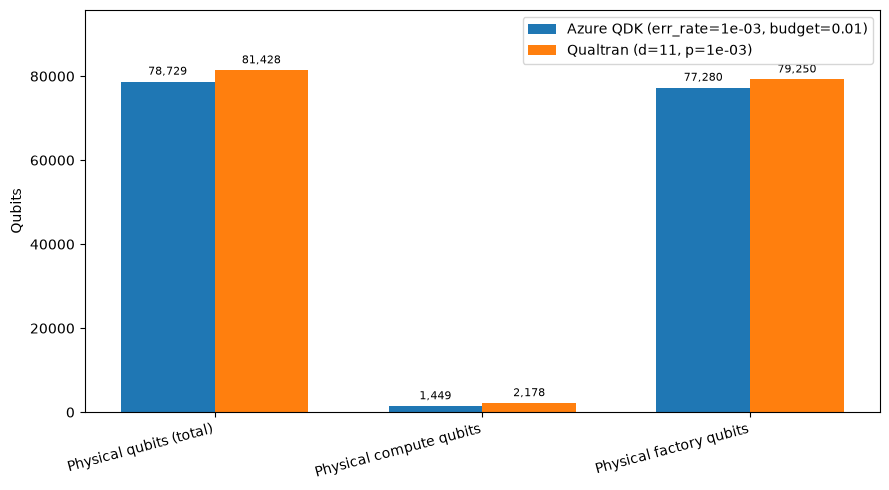

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

names = report.estimator_names
metrics = ["Physical qubits (total)", "Physical compute qubits", "Physical factory qubits"]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(metrics))
width = 0.35

for i, name in enumerate(names):
    vals = [report.get_metric(m).values.get(name) or 0 for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=name)
    ax.bar_label(bars, labels=[f"{v:,}" for v in vals], padding=3, fontsize=8)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(metrics, rotation=15, ha="right")
ax.set_ylabel("Qubits")
ax.set_ylim(0, ax.get_ylim()[1] * 1.12)
ax.legend()
plt.tight_layout()

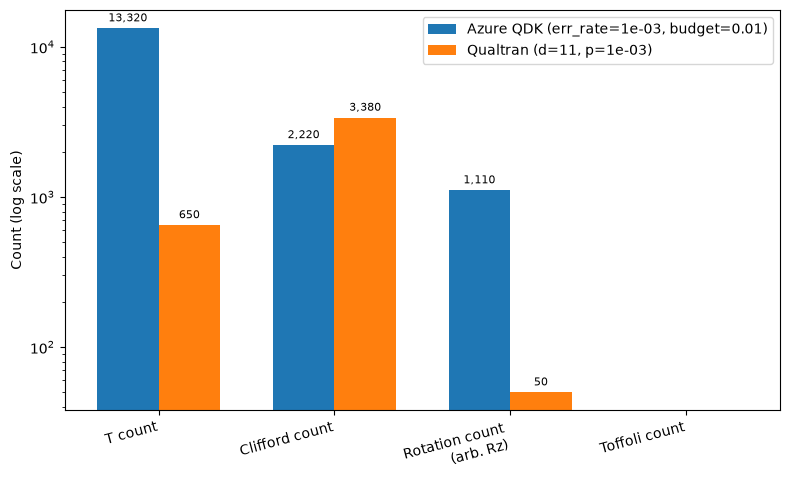

In [ ]:
gate_metrics = ["T count", "Clifford count", "Rotation count", "Toffoli count"]
gate_labels  = ["T count", "Clifford count", "Rotation count\n(arb. Rz)", "Toffoli count"]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(gate_metrics))
width = 0.35

for i, name in enumerate(names):
    vals = [report.get_metric(m).values.get(name) or 0 for m in gate_metrics]
    bars = ax.bar(x + i * width, vals, width, label=name)
    ax.bar_label(bars, labels=[f"{v:,}" if v else "0" for v in vals], padding=3, fontsize=8)

ax.set_yscale("log")
ax.set_xticks(x + width / 2)
ax.set_xticklabels(gate_labels, rotation=15, ha="right")
ax.set_ylabel("Count (log scale)")
ax.legend()
plt.tight_layout()

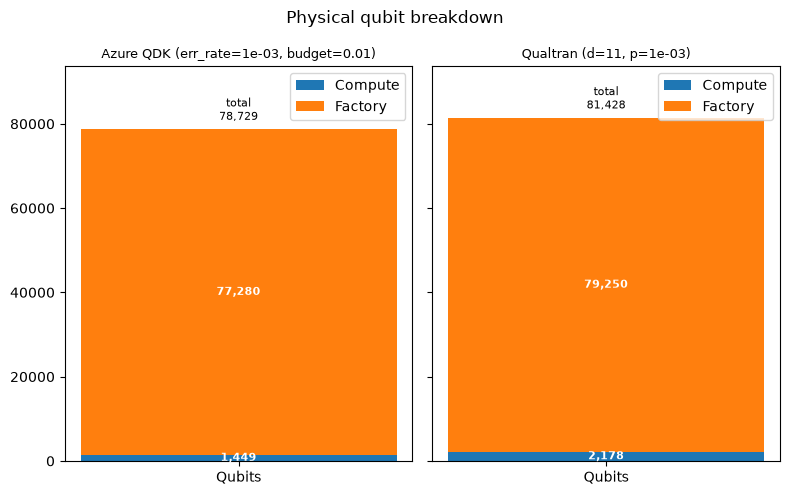

In [ ]:
fig, axes = plt.subplots(1, len(names), figsize=(8, 5), sharey=True)

y_max = 0
for ax, name in zip(axes, names):
    compute = report.get_metric("Physical compute qubits").values.get(name) or 0
    factory = report.get_metric("Physical factory qubits").values.get(name) or 0
    # print(compute, factory)
    b1 = ax.bar(["Qubits"], [compute], label="Compute")
    b2 = ax.bar(["Qubits"], [factory], bottom=[compute], label="Factory")
    ax.bar_label(b1, labels=[f"{compute:,}"], label_type="center", fontsize=8, color="white", fontweight="bold")
    ax.bar_label(b2, labels=[f"{factory:,}"], label_type="center", fontsize=8, color="white", fontweight="bold")
    ax.bar_label(b2, labels=[f"total\n{compute + factory:,}"], padding=4, fontsize=8)
    if ((compute + factory) * 1.15 > y_max):
        y_max = (compute + factory) * 1.15
    ax.set_ylim(0, y_max)  # add headroom
    ax.set_title(name, fontsize=9)
    ax.legend()

plt.suptitle("Physical qubit breakdown")
plt.tight_layout()

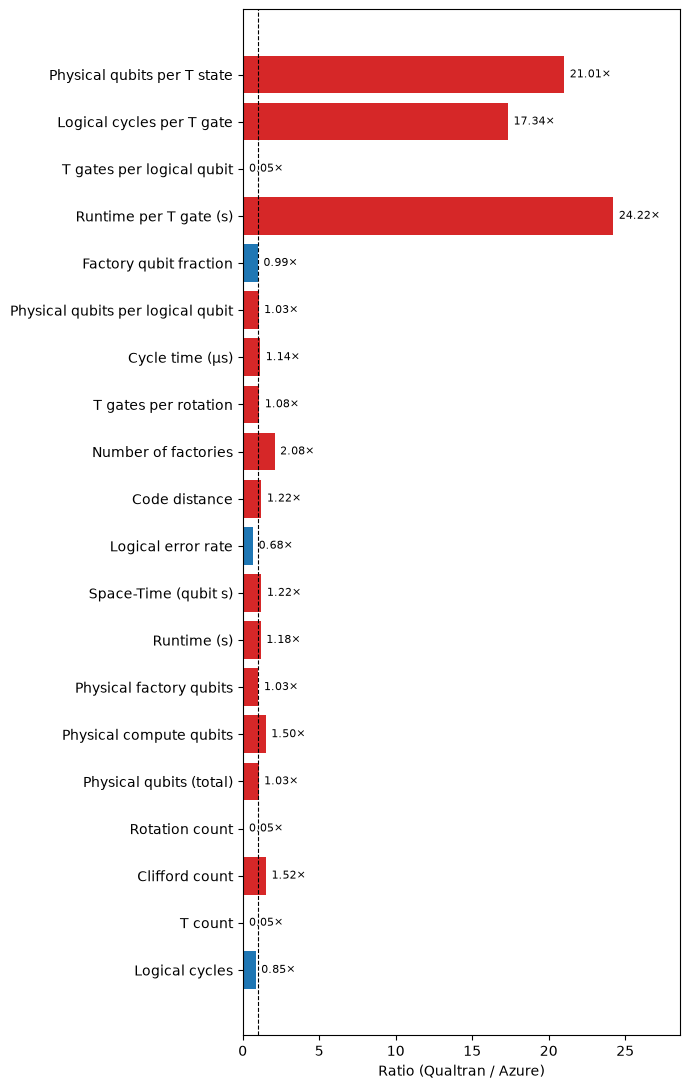

In [ ]:
diffs = [(m.metric, m.ratio) for m in report.differences if m.ratio is not None]
labels, ratios = zip(*diffs)

fig, ax = plt.subplots(figsize=(7, len(labels) * 0.5 + 1))
colors = ["tab:red" if r > 1 else "tab:blue" for r in ratios]
bars = ax.barh(labels, ratios, color=colors)
ax.bar_label(bars, labels=[f"{r:.2f}×" for r in ratios], padding=4, fontsize=8)
ax.set_xlim(0, max(ratios) * 1.18)
ax.axvline(1.0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Ratio (Qualtran / Azure)")
plt.tight_layout()